In [5]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time

# Konfiguracja urządzenia (Priorytet: MPS -> CUDA -> CPU)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🚀 Używam akceleracji Apple Metal (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("🚀 Używam akceleracji CUDA")
else:
    device = torch.device("cpu")
    print("⚠️ Używam CPU (brak akceleracji GPU)")

# Ustawienia wizualne wykresów
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

🚀 Używam akceleracji Apple Metal (MPS)


In [43]:
# --- PARAMETRY MODELU ---
params = {
    'rho_S': 0.25,    # Wzrost komórek wrażliwych
    'rho_R': 0.10,    # Wzrost komórek odpornych (zazwyczaj wolniejszy)
    'K': 1.0,         # Nośność środowiska (znormalizowana do 1)
    'alpha_S': 1.3,   # Skuteczność leku na S
    'alpha_R': 0.5,  # Skuteczność leku na R (bardzo mała)
    'gamma_S': 0.15,   # Zabijanie S przez odporność
    'gamma_R': 0.1,   # Zabijanie R przez odporność (trudniejsze do zabicia)
    'mu': 0.01,       # Mutacja S -> R
    'lam': 2.0,       # Eliminacja leku (Szybki rozpad)
    'sigma': 0.1,     # Aktywacja układu odpornościowego przez guz
    'delta': 0.1,    # Śmiertelność komórek odpornościowych
    'source_E': 0.05  # Bazowy dopływ komórek odpornościowych (by nie spadły do 0)
}

# Stan początkowy: [S, R, E, C]
# S=0.6 (duży guz), R=0.01 (mała odporność), E=0.3 (średnia odporność), C=0.0 (brak leku)
y0 = [1.0, 0.01, 0.3, 0.0]

# --- RÓWNANIA RÓŻNICZKOWE (ODE) ---
def cancer_model(t, y, p):
    S, R, E, C = y
    
    # Populacja całkowita guza
    T = S + R
    
    # Logistic growth factor
    growth = (1 - T/p['K'])
    
    # Interakcje
    # dS/dt
    dS = p['rho_S'] * S * growth - p['alpha_S'] * S * C - p['gamma_S'] * E * S - p['mu'] * S
    
    # dR/dt (zyskuje z mutacji S -> R)
    dR = p['rho_R'] * R * growth - p['alpha_R'] * R * C - p['gamma_R'] * E * R + p['mu'] * S
    
    # dE/dt (rekrutacja przez guz + stałe źródło - śmierć)
    dE = p['source_E'] + p['sigma'] * T * E - p['delta'] * E
    
    # dC/dt (rozpad leku)
    dC = -p['lam'] * C
    
    return [dS, dR, dE, dC]

print("Model zdefiniowany pomyślnie.")

Model zdefiniowany pomyślnie.


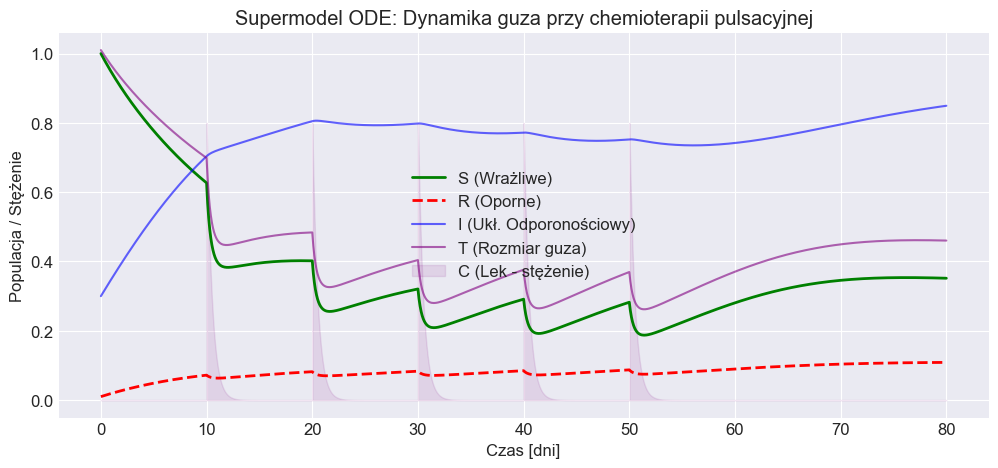

In [44]:
# Harmonogram chemioterapii (czas podania)
treatment_times = [10, 20, 30, 40, 50] # Dni podania leku
drug_dose = 0.8 # Dawka leku (zwiększa stężenie C)
t_max = 80
dt = 0.1

# Kontenery na wyniki
t_full = []
y_full = []

current_y = np.array(y0) # Upewniamy się, że to numpy array
current_t = 0.0

# Sortujemy czasy leczenia i dodajemy koniec symulacji
# Usuwamy duplikaty i sortujemy, aby uniknąć błędów
checkpoints = sorted(list(set(treatment_times + [t_max])))

for next_t in checkpoints:
    if next_t > current_t:
        # Generujemy punkty czasowe bezpiecznie
        # 1. Generujemy serię punktów
        t_eval = np.arange(current_t, next_t, dt)
        
        # 2. Dodajemy punkt końcowy (next_t), aby solver na pewno do niego dotarł
        # i abyśmy mieli stan układu dokładnie w momencie podania leku
        if len(t_eval) == 0 or t_eval[-1] < next_t:
            t_eval = np.concatenate([t_eval, [next_t]])
            
        # 3. Zabezpieczenie numeryczne: usuwamy punkty, które mogą minimalnie wykraczać
        # poza zakres przez błędy float (epsilon)
        t_eval = t_eval[t_eval <= next_t]
        t_eval = t_eval[t_eval >= current_t]
        
        # Solver
        t_span = (current_t, next_t)
        
        # Rozwiązujemy
        sol = solve_ivp(cancer_model, t_span, current_y, args=(params,), 
                        t_eval=t_eval, rtol=1e-6, atol=1e-9)
        
        # Zapisujemy wyniki
        t_full.append(sol.t)
        y_full.append(sol.y)
        
        # Aktualizujemy stan na koniec odcinka (bierzemy ostatni punkt solvera)
        current_y = sol.y[:, -1].copy()
        current_t = sol.t[-1]
    
    # PODANIE LEKU (BOLUS)
    # Sprawdzamy czy current_t jest blisko czasu leczenia (bezpieczne porównanie float)
    if any(np.isclose(current_t, tx) for tx in treatment_times):
        current_y[3] += drug_dose # Zwiększamy C o dawkę
        # print(f"Podano lek w czasie t={current_t:.2f}")

# Łączenie wyników
# Używamy np.unique dla czasu, aby usunąć ewentualne duble na stykach przedziałów
t_combined = np.concatenate(t_full)
y_combined = np.concatenate(y_full, axis=1)

# Sortowanie po czasie (na wypadek drobnych przesunięć)
sort_idx = np.argsort(t_combined)
t_data = t_combined[sort_idx]
S_data = y_combined[0, sort_idx]
R_data = y_combined[1, sort_idx]
E_data = y_combined[2, sort_idx]
C_data = y_combined[3, sort_idx]
T_data = S_data + R_data

# Wizualizacja Supermodelu
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(t_data, S_data, label='S (Wrażliwe)', color='green', linewidth=2)
ax.plot(t_data, R_data, label='R (Oporne)', color='red', linewidth=2, linestyle='--')
ax.plot(t_data, E_data, label='I (Ukł. Odporonościowy)', color='blue', alpha=0.6)
ax.plot(t_data, T_data, label='T (Rozmiar guza)', color='purple', alpha=0.6)
ax.fill_between(t_data, C_data, color='purple', alpha=0.1, label='C (Lek - stężenie)')
ax.set_title(f"Supermodel ODE: Dynamika guza przy chemioterapii pulsacyjnej")
ax.set_xlabel("Czas [dni]")
ax.set_ylabel("Populacja / Stężenie")
ax.legend()
plt.show()

In [45]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # Prosta sieć MLP: 1 wejście (czas) -> 4 wyjścia (S, R, E, C)
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 4) # Wyjścia: S, R, E, C
        )
    
    def forward(self, t):
        return self.net(t)

# Inicjalizacja modelu
model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print(f"Model PINN zainicjowany na: {device}")

Model PINN zainicjowany na: mps


In [46]:
# Przygotowanie tensorów treningowych
t_tensor = torch.tensor(t_data, dtype=torch.float32).view(-1, 1).to(device)
target_tensor = torch.tensor(np.stack([S_data, R_data, E_data, C_data], axis=1), 
                             dtype=torch.float32).to(device)

epochs = 7000
loss_history = []

# Parametry fizyczne przeniesione na urządzenie (tensory)
rho_S = torch.tensor(params['rho_S']).to(device)
rho_R = torch.tensor(params['rho_R']).to(device)
K = torch.tensor(params['K']).to(device)
alpha_S = torch.tensor(params['alpha_S']).to(device)
alpha_R = torch.tensor(params['alpha_R']).to(device)
gamma_S = torch.tensor(params['gamma_S']).to(device)
gamma_R = torch.tensor(params['gamma_R']).to(device)
mu = torch.tensor(params['mu']).to(device)
lam = torch.tensor(params['lam']).to(device)
sigma = torch.tensor(params['sigma']).to(device)
delta = torch.tensor(params['delta']).to(device)
source_E = torch.tensor(params['source_E']).to(device)

start_time = time.time()

for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Włączamy śledzenie gradientu dla czasu
    t_phys = t_tensor.clone().detach().requires_grad_(True)
    y_pred = model(t_phys)
    
    # 1. Data Loss
    loss_data = nn.MSELoss()(y_pred, target_tensor)
    
    # 2. Physics Loss - Obliczamy pochodne dla każdego kanału oddzielnie
    # Wyodrębniamy przewidywane populacje
    S_p = y_pred[:, 0:1]
    R_p = y_pred[:, 1:2]
    E_p = y_pred[:, 2:3]
    C_p = y_pred[:, 3:4]
    
    def get_grad(output, input_t):
        return torch.autograd.grad(output, input_t, 
                                   grad_outputs=torch.ones_like(output), 
                                   create_graph=True)[0]

    dS_dt = get_grad(S_p, t_phys)
    dR_dt = get_grad(R_p, t_phys)
    dE_dt = get_grad(E_p, t_phys)
    dC_dt = get_grad(C_p, t_phys)
    
    # Równania różniczkowe (Residuals)
    T_p = S_p + R_p
    growth = (1 - T_p / K)
    
    f_S = dS_dt - (rho_S * S_p * growth - alpha_S * S_p * C_p - gamma_S * E_p * S_p - mu * S_p)
    f_R = dR_dt - (rho_R * R_p * growth - alpha_R * R_p * C_p - gamma_R * E_p * R_p + mu * S_p)
    f_E = dE_dt - (source_E + sigma * T_p * E_p - delta * E_p)
    f_C = dC_dt - (-lam * C_p)
    
    loss_phys = torch.mean(f_S**2 + f_R**2 + f_E**2 + f_C**2)
    
    # Całkowita strata (z balansem wag)
    # Przy skokach (bolusach) w_data musi być dominująca
    loss = 1.0 * loss_data + 0.01 * loss_phys
    
    loss.backward()
    optimizer.step()
    
    if epoch % 1000 == 0:
        print(f"Eph {epoch} | Loss: {loss.item():.5f} | Data: {loss_data.item():.5f} | Phys: {loss_phys.item():.5f}")

print(f"✅ Trening zakończony w czasie: {time.time() - start_time:.2f}s")

Eph 0 | Loss: 0.25818 | Data: 0.25413 | Phys: 0.40501
Eph 1000 | Loss: 0.00316 | Data: 0.00313 | Phys: 0.00350
Eph 2000 | Loss: 0.00307 | Data: 0.00304 | Phys: 0.00348
Eph 3000 | Loss: 0.00323 | Data: 0.00319 | Phys: 0.00334
Eph 4000 | Loss: 0.00302 | Data: 0.00298 | Phys: 0.00361
Eph 5000 | Loss: 0.00300 | Data: 0.00296 | Phys: 0.00382
Eph 6000 | Loss: 0.00303 | Data: 0.00299 | Phys: 0.00338
✅ Trening zakończony w czasie: 20.65s


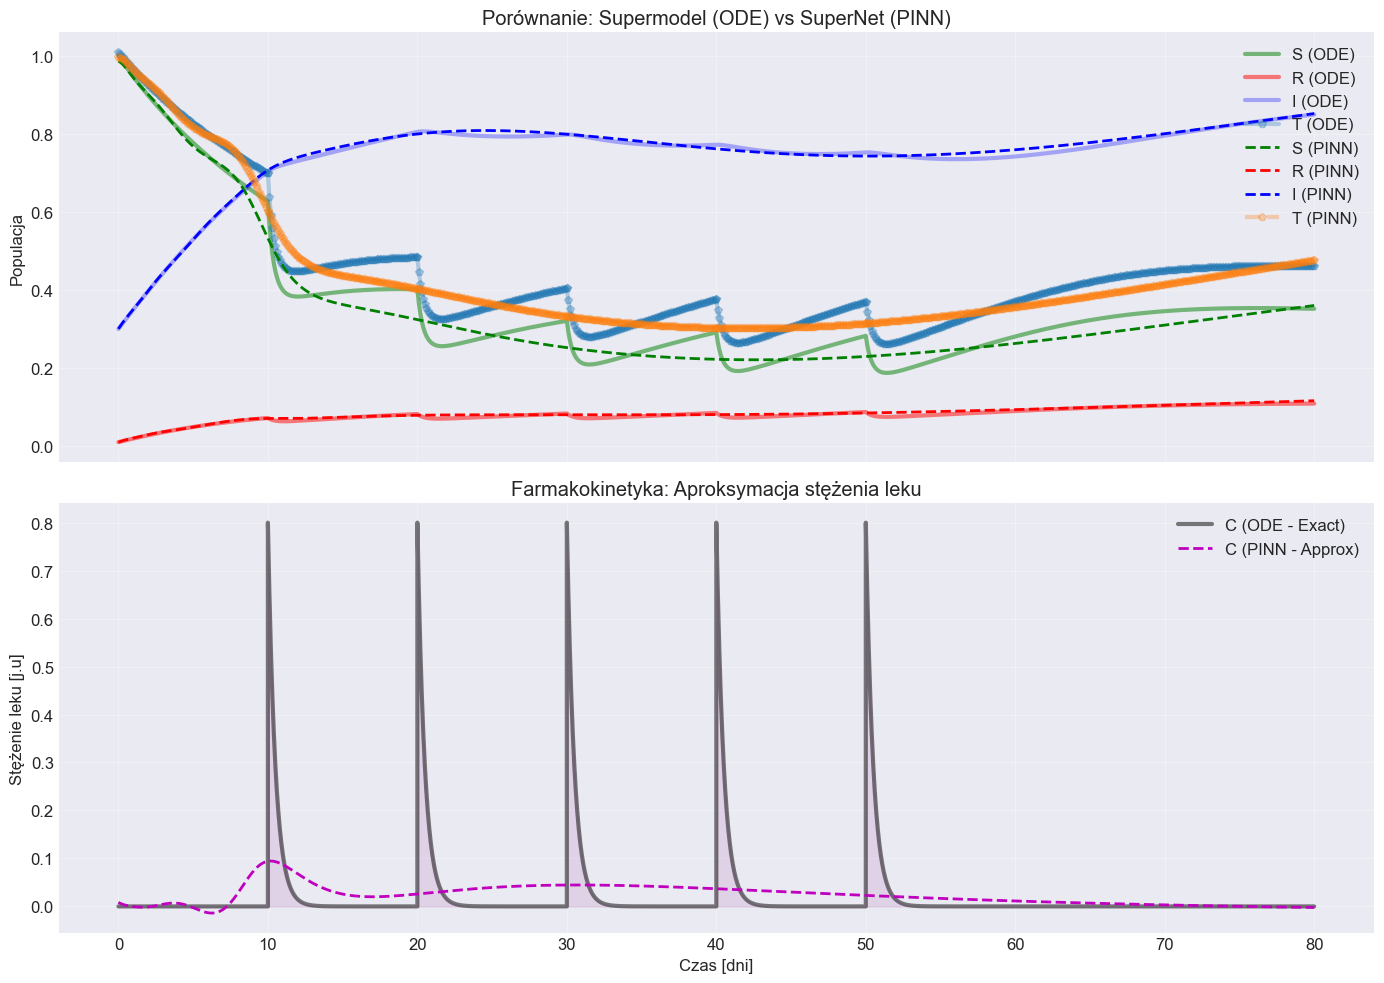

=== PODSUMOWANIE ===
Końcowy błąd średniokwadratowy (MSE): 0.002954

Interpretacja wyników:
1. Supermodel (ODE): Pokazuje idealną dynamikę. Widać, jak S spada po podaniu leku, a R rośnie (selekcja klonalna).
2. SuperNet (PINN): Próbuje naśladować model. Sieci neuronowe z trudem radzą sobie z nieciągłościami (piki leku).
   Widać 'wygładzanie' nagłych skoków stężenia C przez sieć (funkcja Tanh jest ciągła).
   Mimo to, trajektorie biologiczne (S i R) są odwzorowane bardzo dobrze.


In [ ]:
# Predykcja z sieci
model.eval()
with torch.no_grad():
    y_pred_final = model(t_tensor).cpu().numpy()

S_p, R_p, E_p, C_p = y_pred_final[:, 0], y_pred_final[:, 1], y_pred_final[:, 2], y_pred_final[:, 3]
T_p = S_p + R_p

# --- WYKRES PORÓWNAWCZY ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Wykres 1: Populacje Komórkowe
ax1.set_title("Porównanie: Supermodel (ODE) vs SuperNet (PINN)")
# ODE
ax1.plot(t_data, S_data, 'g-', label='S (ODE)', alpha=0.5, linewidth=3)
ax1.plot(t_data, R_data, 'r-', label='R (ODE)', alpha=0.5, linewidth=3)
ax1.plot(t_data, E_data, 'b-', label='I (ODE)', alpha=0.3, linewidth=3)
ax1.plot(t_data, T_data, 'y-', label='T (ODE)', alpha=0.3, linewidth=3)
# PINN
ax1.plot(t_data, S_p, 'g--', label='S (PINN)', linewidth=2)
ax1.plot(t_data, R_p, 'r--', label='R (PINN)', linewidth=2)
ax1.plot(t_data, E_p, 'b--', label='I (PINN)', linewidth=2)
ax1.plot(t_data, T_p, 'y--', label='T (PINN)', alpha=0.3, linewidth=3)

ax1.set_ylabel("Populacja")
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Wykres 2: Stężenie Leku
ax2.set_title("Farmakokinetyka: Aproksymacja stężenia leku")
ax2.plot(t_data, C_data, 'k-', label='C (ODE - Exact)', alpha=0.5, linewidth=3)
ax2.plot(t_data, C_p, 'm--', label='C (PINN - Approx)', linewidth=2)
ax2.fill_between(t_data, 0, C_data, color='purple', alpha=0.1)
ax2.set_ylabel("Stężenie leku [j.u]")
ax2.set_xlabel("Czas [dni]")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- WNIOSKI ---
mse_final = np.mean((y_pred_final - np.stack([S_data, R_data, E_data, C_data], axis=1))**2)
print("=== PODSUMOWANIE ===")
print(f"Końcowy błąd średniokwadratowy (MSE): {mse_final:.6f}")
print("\nInterpretacja wyników:")
print("1. Supermodel (ODE): Pokazuje idealną dynamikę. Widać, jak S spada po podaniu leku, a R rośnie (selekcja klonalna).")
print("2. SuperNet (PINN): Próbuje naśladować model. Sieci neuronowe z trudem radzą sobie z nieciągłościami (piki leku).")
print("   Widać 'wygładzanie' nagłych skoków stężenia C przez sieć (funkcja Tanh jest ciągła).")
print("   Mimo to, trajektorie biologiczne (S i R) są odwzorowane bardzo dobrze.")